### Prior elicitation 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions


import cmdstanpy
import os
from pathlib import Path

import os, sys
from pathlib import Path
def set_project_root():
        
    # Find and navigate to Progetto_Bayesian_Statistics
    current = Path.cwd()

    # Check if we're already there
    if current.name == 'Progetto_Bayesian_Statistics':
        print(f"Already in project root: {current}")
    else:
        # Search up to parent directories
        for parent in [current] + list(current.parents):
            if parent.name == 'Progetto_Bayesian_Statistics':
                os.chdir(parent)
                print(f"Changed to: {parent}")
                break
        else:
            raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

    # Verify
    assert Path('src').exists(), "src/ folder not found"
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir()}")


    # Create ./stan folder if does not exists
    STAN_PATH = "./src/stan_models/"
    print(cmdstanpy.cmdstan_path())
    return STAN_PATH

STAN_PATH = set_project_root()
print("cwd:", os.getcwd())
print("first sys.path entries:")
for p in sys.path[:5]:
    print("  ", p)

print("project root guess:", Path().resolve())
print("exists ./src ?", (Path().resolve() / "src").exists())

from src.utils.utils import *

/opt/Projects/.envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Changed to: /opt/Projects/Progetto_Bayesian_Statistics
Current directory: /opt/Projects/Progetto_Bayesian_Statistics
Contents: ['.git', '.gitignore', '.gitattributes', 'requirements.bk.txt', 'README.md', 'configs_table.txt', 'table.txt', 'data', 'results', 'requirements.txt', 'materials', 'src']
/home/ahbagheri/.cmdstan/cmdstan-2.38.0
cwd: /opt/Projects/Progetto_Bayesian_Statistics
first sys.path entries:
   /usr/lib/python312.zip
   /usr/lib/python3.12
   /usr/lib/python3.12/lib-dynload
   
   /opt/Projects/.envs/ML/lib/python3.12/site-packages
project root guess: /opt/Projects/Progetto_Bayesian_Statistics
exists ./src ? True


In [2]:
data, data_donors = transform_data()
glm_data, X_D = get_glm_data(data, data_donors)

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]


In [3]:
model_names = model_names = [
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.72, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.72, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.72, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.72, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.08, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.08, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.08, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.08, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":4.5, "sigma_beta_sq_a":3, "sigma_beta_sq_b":4.5, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":4.5, "sigma_beta_sq_a":3, "sigma_beta_sq_b":4.5, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":0.18, "sigma_beta_sq_a":3, "sigma_beta_sq_b":2.0, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":3, "tau_sq_b":2.0, "sigma_beta_sq_a":3, "sigma_beta_sq_b":0.18, "mu_alpha_0":0, "sigma_alpha_0":10}),


    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":0.09, "sigma_beta_sq_a":2, "sigma_beta_sq_b":0.09, "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":0.09, "sigma_beta_sq_a":2, "sigma_beta_sq_b":0.09, "mu_alpha_0":0, "sigma_alpha_0":10}),
    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":1.0,  "sigma_beta_sq_a":2, "sigma_beta_sq_b":1.0,  "mu_alpha_0":0, "sigma_alpha_0":5}),
    ("sr_invgamma.stan", {"tau_sq_a":2, "tau_sq_b":1.0,  "sigma_beta_sq_a":2, "sigma_beta_sq_b":1.0,  "mu_alpha_0":0, "sigma_alpha_0":10}),
    
    ("sr_tstudent.stan", {"student_df":3,"student_scale":0.5,"mu_alpha_0":0,"sigma_alpha_0":1}),
    ("sr_tstudent.stan", {"student_df":3,"student_scale":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_tstudent.stan", {"student_df":3,"student_scale":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_halfnormal.stan", {"sigma_b":0.5,"mu_alpha_0":0,"sigma_alpha_0":1}),
    ("sr_halfnormal.stan", {"sigma_b":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_halfnormal.stan", {"sigma_b":1,"mu_alpha_0":0,"sigma_alpha_0":10})
]

models = {}
for key in model_names:
    print(f"Compiling model: {key}")
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key[0]}")
    for x in X_D:
        if x == "X2":
            print(f"Fitting model: {key} with {x} (skipped)")
            continue
        models[(key[0], tuple(key[1].items()), x)] = {"model": glm, "X": X_D[x]}
        new_data = glm_data.copy()
        new_data.update({"X": X_D[x], "p": X_D[x].shape[1]})
        new_data.update(key[1])
        models[(key[0], tuple(key[1].items()), x)]["data"] = new_data

Compiling model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 5})
Fitting model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 5}) with X2 (skipped)
Compiling model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 10})
Fitting model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.18, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.18, 'mu_alpha_0': 0, 'sigma_alpha_0': 10}) with X2 (skipped)
Compiling model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.72, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.72, 'mu_alpha_0': 0, 'sigma_alpha_0': 5})
Fitting model: ('sr_invgamma.stan', {'tau_sq_a': 3, 'tau_sq_b': 0.72, 'sigma_beta_sq_a': 3, 'sigma_beta_sq_b': 0.72, 'mu_alpha_0': 0, 'sigma_alpha_0': 5}) with X2 (skipped)
Compilin

In [4]:
len(models)

46

In [5]:
import os
remove_keys = []
for key in models:
    filename = f"{'_'.join(str(k) for k in key)}.nc"
    try:
        models[key]["az"] = az.from_netcdf(f"./results/sr_prolic/{filename}")
    except FileNotFoundError:
        remove_keys.append(key)
        pass




In [6]:
for k in remove_keys:
    print(f"Removing {k} due to missing file")
    del models[k]

Removing ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') due to missing file
Removing ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I') due to missing file
Removing ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X') due to missing file
Removing ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.08), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.08), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I') due to missing file
Removing ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 4.5), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 4.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') due to missing file
Removing ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 4.5

In [7]:
len(models)

22

In [8]:
for key in models:
    poi_glm_data = models[key]["az"]
    print("divergence of ", key,np.sum(poi_glm_data.sample_stats.diverging))

divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I') <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3)

In [9]:
# for key in models:
#     poi_glm_data = models[key]["az"]
#     az.plot_trace(poi_glm_data, var_names=["beta"], compact=False)
#     plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
#     plt.tight_layout()
#     plt.show()

In [10]:

# for key in models:
#     poi_glm_data = models[key]["az"]
#     az.plot_autocorr(poi_glm_data, var_names=["beta"])
#     plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
#     plt.tight_layout()
#     plt.show() 

In [11]:
model_names = list(models.keys())
# models[model_names[0]]["fit"].summary()

In [12]:
for key in models:
    poi_glm_data = models[key]["az"]
    
    # Divergences
    n_divergences = np.sum(poi_glm_data.sample_stats.diverging.values)
    total_samples = poi_glm_data.sample_stats.diverging.size
    pct_divergence = 100 * n_divergences / total_samples
    
    print(f"\n{key}:")
    print(f"  Divergences: {n_divergences} ({pct_divergence:.2f}%)")
    
    # ESS
    ess = az.ess(poi_glm_data)
    print(f"  ESS beta: {ess['beta'].values}")
    print(f"  ESS beta_random shape: {ess['beta_random'].values.shape}")
    print(f"  ESS beta_random:\n{ess['beta_random'].values}")
    print(f"  ESS alpha: {ess['alpha'].values}")
    print(f"  ESS mu_chi: {ess['mu_chi'].values}")
    print(f"  ESS sigma_chi: {ess['sigma_chi'].values}")


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X'):
  Divergences: 0 (0.00%)
  ESS beta: [ 4536.10133653 37849.63863572 36672.01466882  4908.74870552]
  ESS beta_random shape: (8, 3)
  ESS beta_random:
[[ 5358.82534105  5523.18219966  5499.84901072]
 [ 4950.418475    5017.44308472  4983.38433616]
 [ 5285.17543789  5304.84945225  5344.44001854]
 [ 4956.38382029  5002.16214221  5002.95071749]
 [ 6224.58522816  6598.16993608  6162.79968884]
 [ 5684.02147652  5403.90003222  5440.64149809]
 [ 5173.7557711   5229.93105289 33376.73683099]
 [ 4959.53505353  4973.83724086 34754.45203097]]
  ESS alpha: [27134.43577425 34808.56486286 30205.03952354 32896.72883162
 30186.02933631 31251.33439798 31610.02281111 32705.00063725]
  ESS mu_chi: 19685.800453686883
  ESS sigma_chi: 20086.35058030574

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b'

In [13]:
def plot_confident_intervals(model_fit, var_name="beta", skip_intercept=True):
    sum_var = az.summary(model_fit, var_names=[var_name], hdi_prob=0.95)
    
    if skip_intercept:
        names = sum_var.index.to_list()[1:]
        mean = sum_var["mean"].values[1:]
        low = sum_var["hdi_2.5%"].values[1:]
        high = sum_var["hdi_97.5%"].values[1:]
    else:
        names = sum_var.index.to_list()
        mean = sum_var["mean"].values
        low = sum_var["hdi_2.5%"].values
        high = sum_var["hdi_97.5%"].values
    
    y = np.arange(len(names))

    plt.figure(figsize=(6, max(3, 0.3 * len(names))))
    for i in range(len(names)):
        # Color based on whether interval excludes zero
        if low[i] > 0:
            color = "tab:red"  # Positive effect (above zero)
        elif high[i] < 0:
            color = "tab:green"  # Negative effect (below zero)
        else:
            color = "lightgray"  # Includes zero
        
        plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=color)
        plt.plot(mean[i], y[i], "o", color=color)

    plt.axvline(0, color="black", ls="--", alpha=0.7)
    plt.yticks(y, names)
    plt.xlabel(f"{var_name}")
    plt.title(f"Posterior 95% HDI — {var_name}")
    plt.tight_layout()
    plt.show()

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


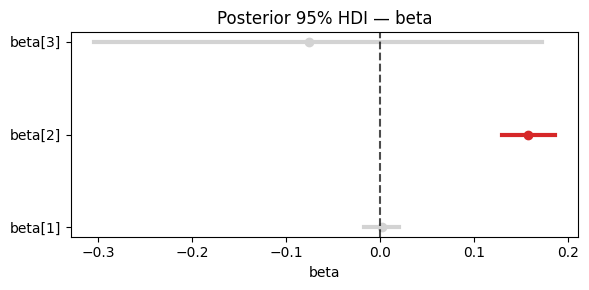

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


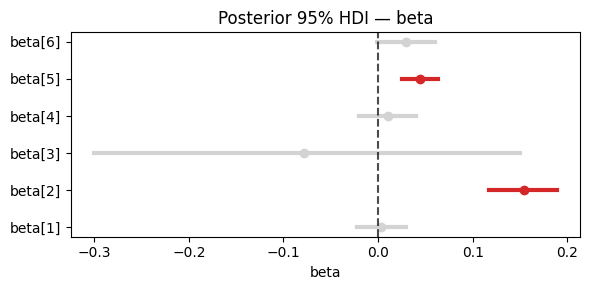

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


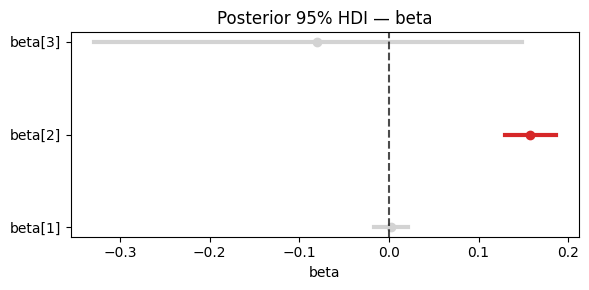

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


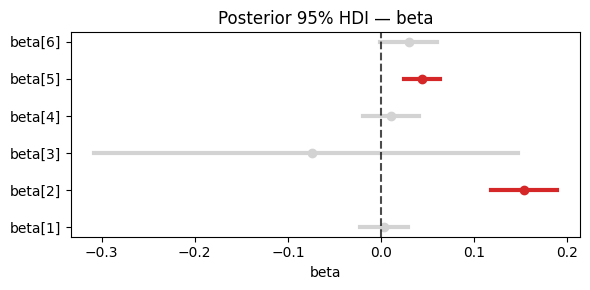

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


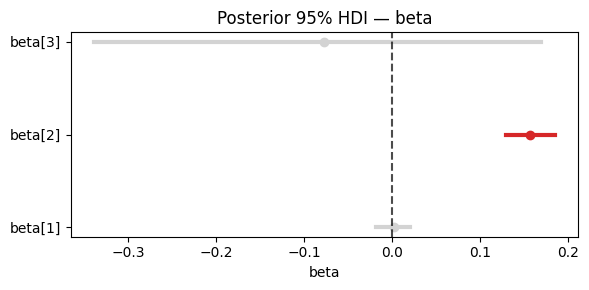

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


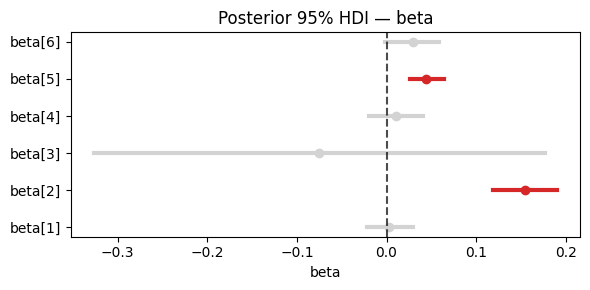

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


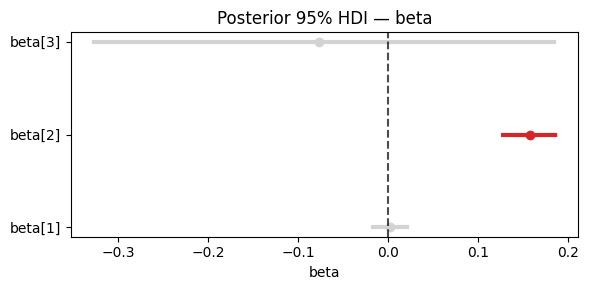

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


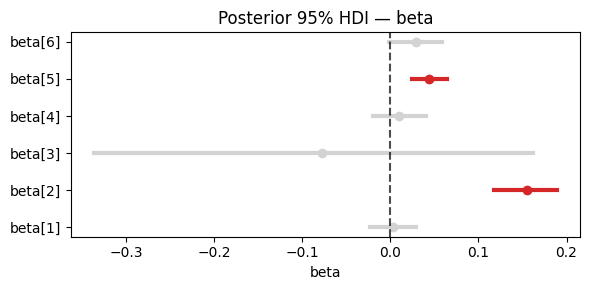

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


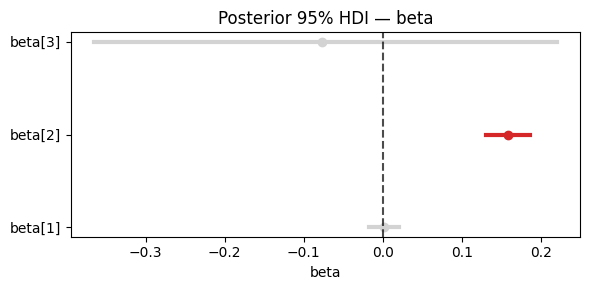

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


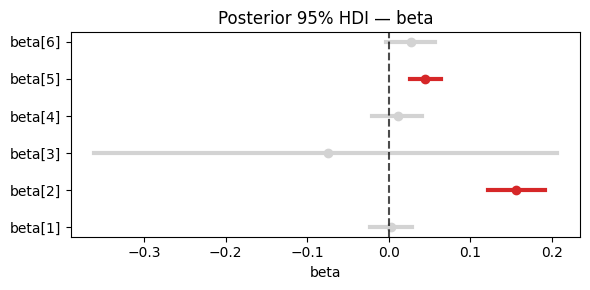

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


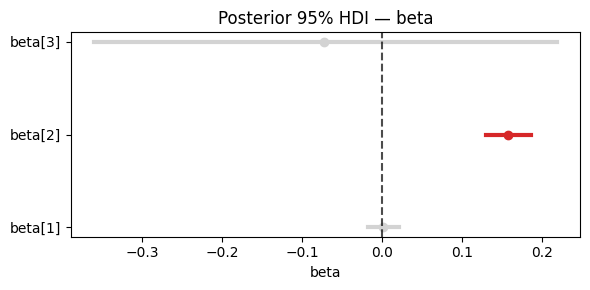

('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


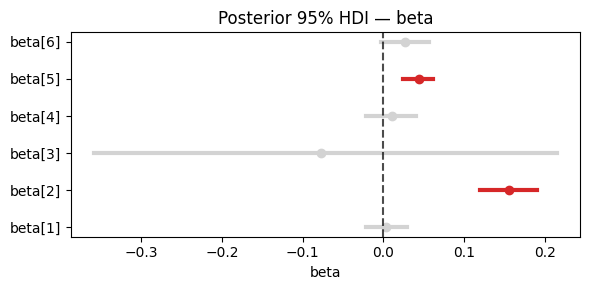

('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X')


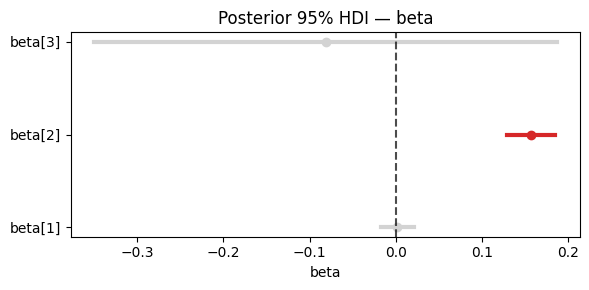

('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X2_I')


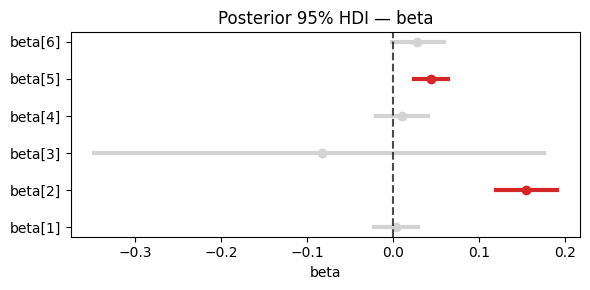

('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


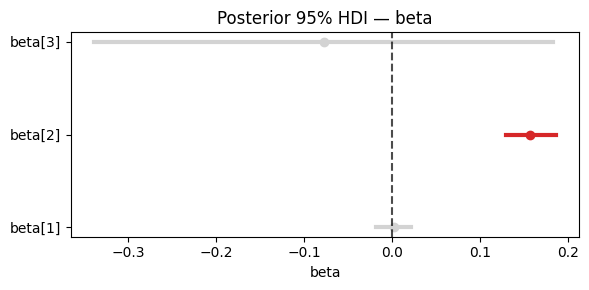

('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


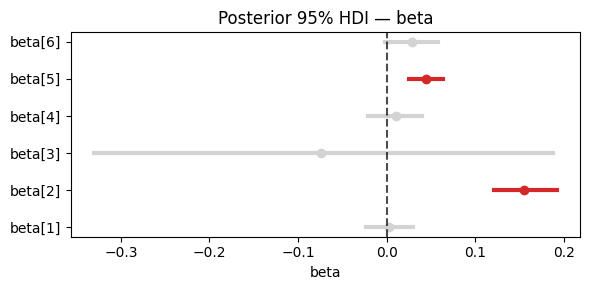

('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X')


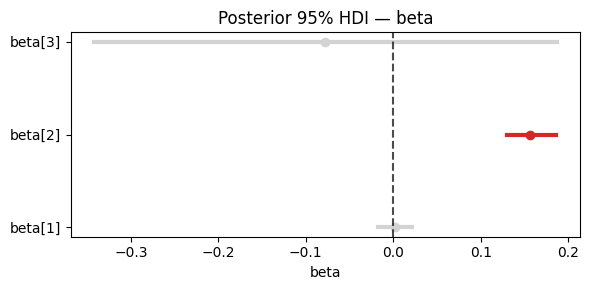

('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X2_I')


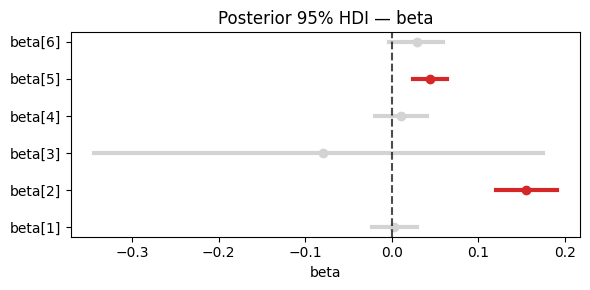

('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


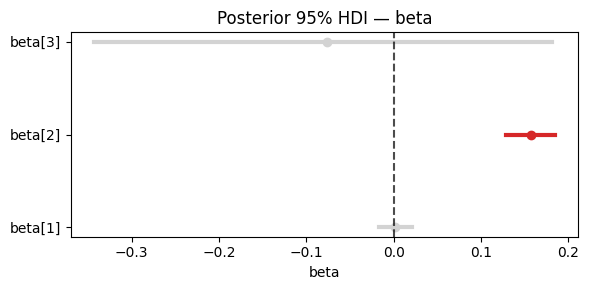

('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


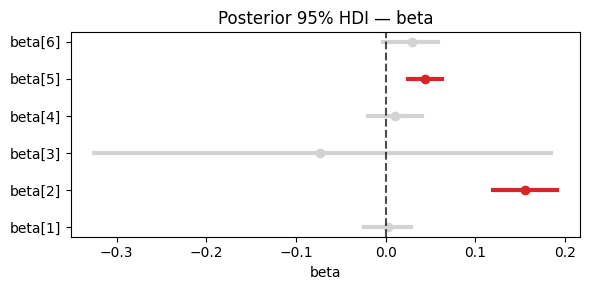

('sr_halfnormal.stan', (('sigma_b', 1), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


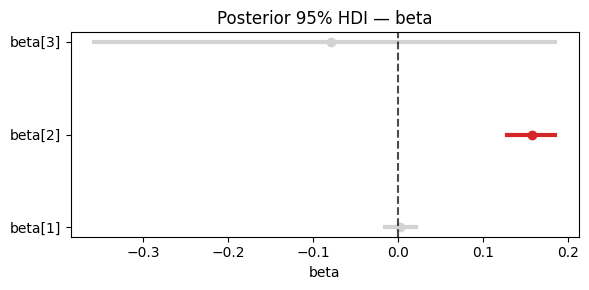

('sr_halfnormal.stan', (('sigma_b', 1), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


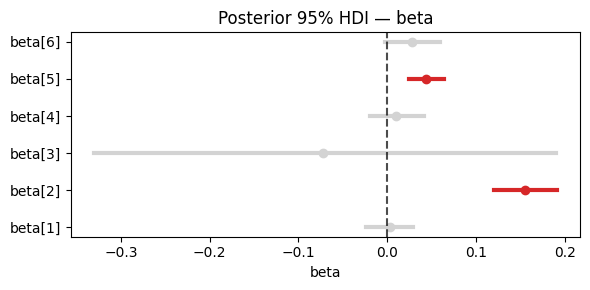

In [14]:
for i in model_names:
    print(i)
    plot_confident_intervals(models[i]["az"], var_name="beta")

In [15]:
# posterior plot (sorted by fitted mean + log scale)
def posterior_predictive_check(yrep, yobs, q_low=0.05, q_high=0.95):

    # compute mean and CI for every observation
    pred_mean = yrep.mean(axis=0)                      # (N,)
    pred_lo   = np.quantile(yrep, q_low,  axis=0)      # (N,)
    pred_hi   = np.quantile(yrep, q_high, axis=0)      # (N,)

    # identify outliers in original scale
    out = (yobs < pred_lo) | (yobs > pred_hi)

    # sort by fitted mean (in original scale)
    order = np.argsort(pred_mean)

    # apply ordering
    yobs_s      = yobs[order]
    pred_mean_s = pred_mean[order]
    pred_lo_s   = pred_lo[order]
    pred_hi_s   = pred_hi[order]
    out_s       = out[order]

    # x-axis is now "rank by fitted mean"
    x = np.arange(len(yobs))

    # log scale for plotting (safe with zeros)
    yobs_l      = np.log1p(yobs_s)
    pred_mean_l = np.log1p(pred_mean_s)
    pred_lo_l   = np.log1p(pred_lo_s)
    pred_hi_l   = np.log1p(pred_hi_s)

    plt.figure(figsize=(12, 5))

    # predictive band (log scale)
    plt.fill_between(
        x, pred_lo_l, pred_hi_l,
        alpha=0.3,
        label=f"{int((q_high-q_low)*100)}% posterior predictive interval (log1p)"
    )

    # predictive mean (log scale)
    plt.scatter(
        x, pred_mean_l,
        linewidth=2,
        label="log(1 + predicted mean)",
        zorder=2
    )

    # observed inliers/outliers (log scale)
    plt.scatter(
        x[~out_s], yobs_l[~out_s],
        s=18,
        label="Observed (inliers)",
        zorder=3
    )
    plt.scatter(
        x[out_s], yobs_l[out_s],
        s=35,
        color="red",
        label="Observed (outliers)",
        zorder=4
    )

    plt.xlabel("Observations (sorted by fitted mean)")
    plt.ylabel("log(1 + y)")
    plt.title(f"PPC (sorted, log-scale) — outliers: {out.sum()} / {len(out)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # return outliers in original order + ordering used (useful to map back)
    return out, order




('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


<Figure size 1000x500 with 0 Axes>

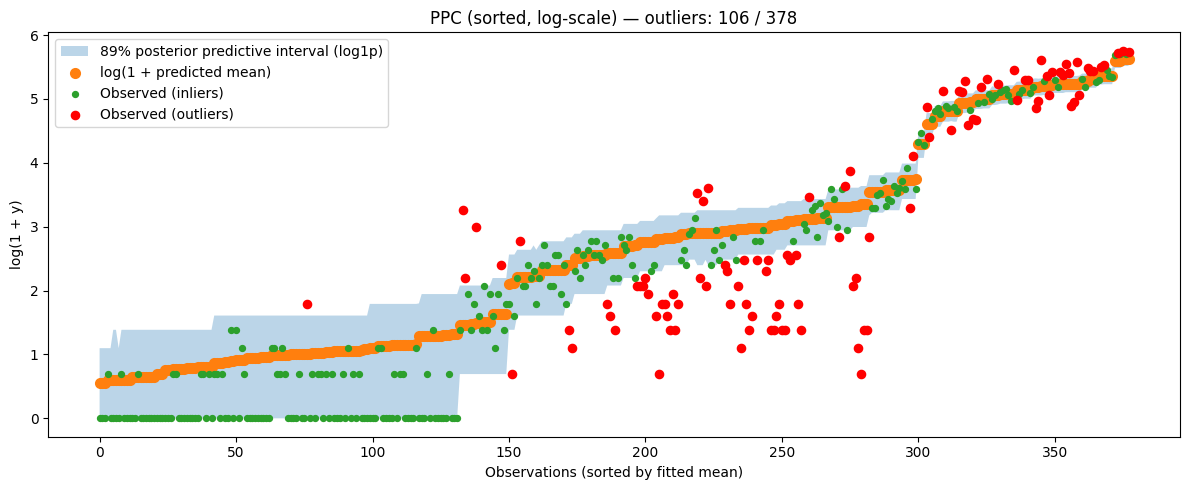

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

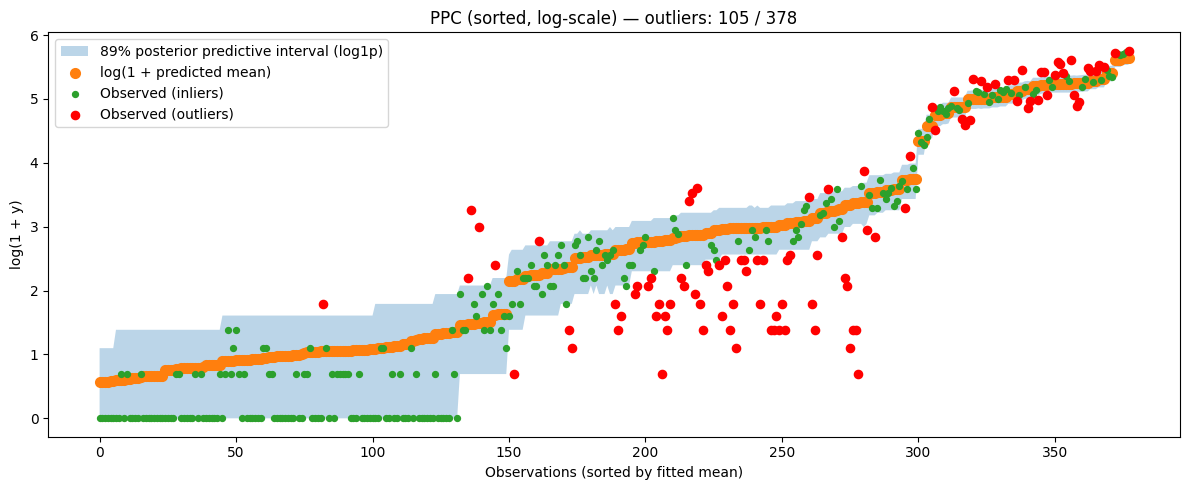

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


<Figure size 1000x500 with 0 Axes>

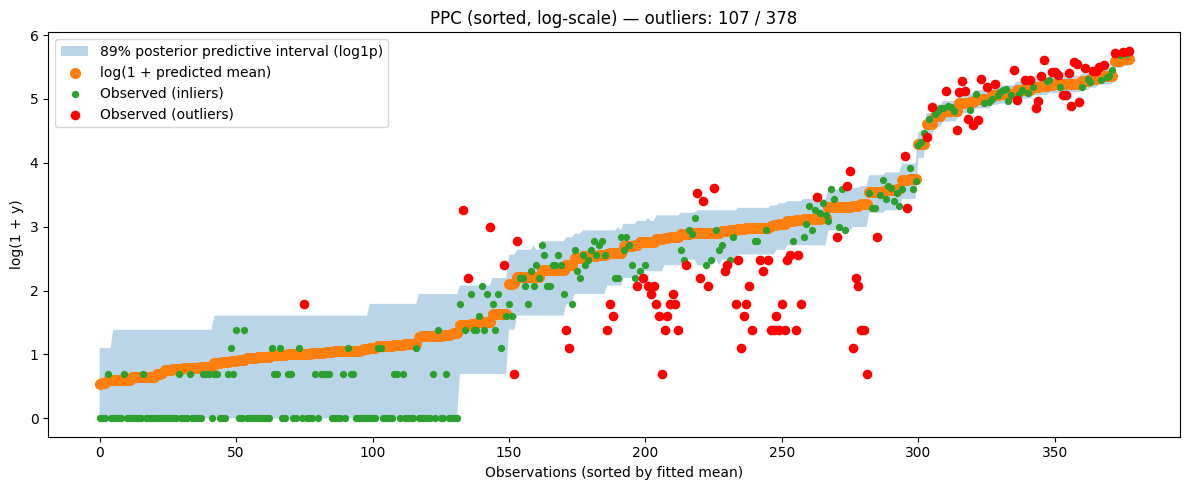

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

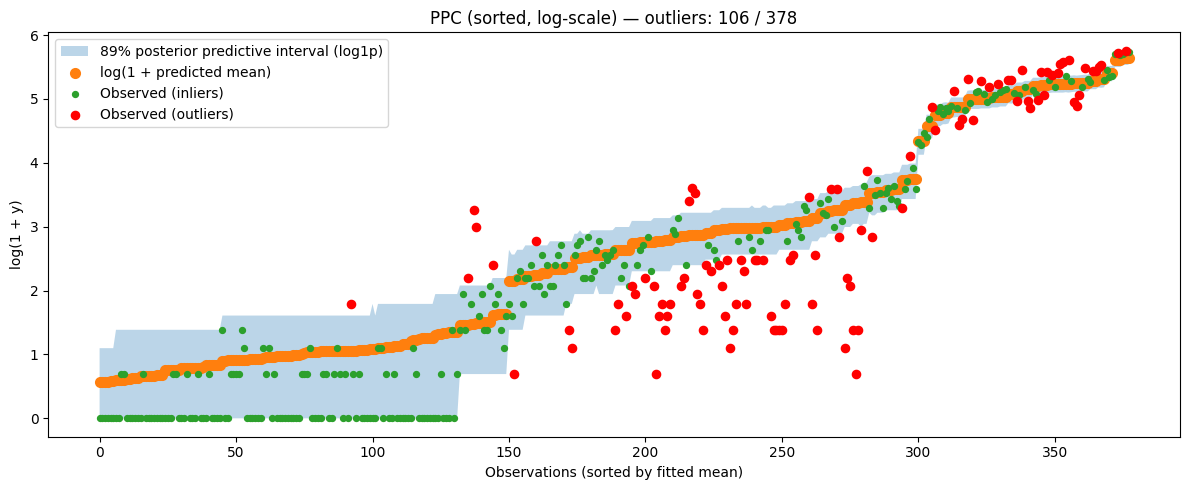

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


<Figure size 1000x500 with 0 Axes>

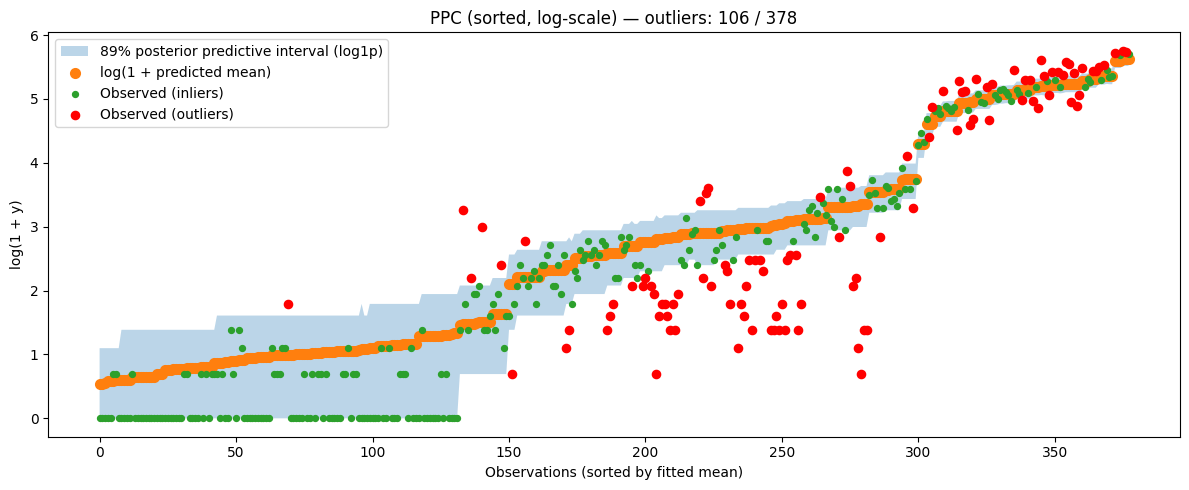

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

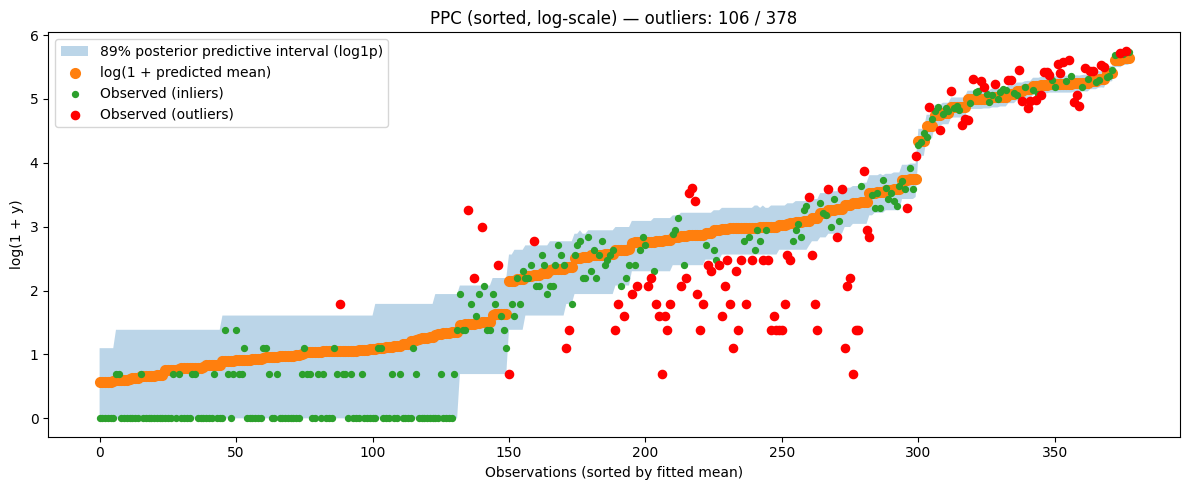

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


<Figure size 1000x500 with 0 Axes>

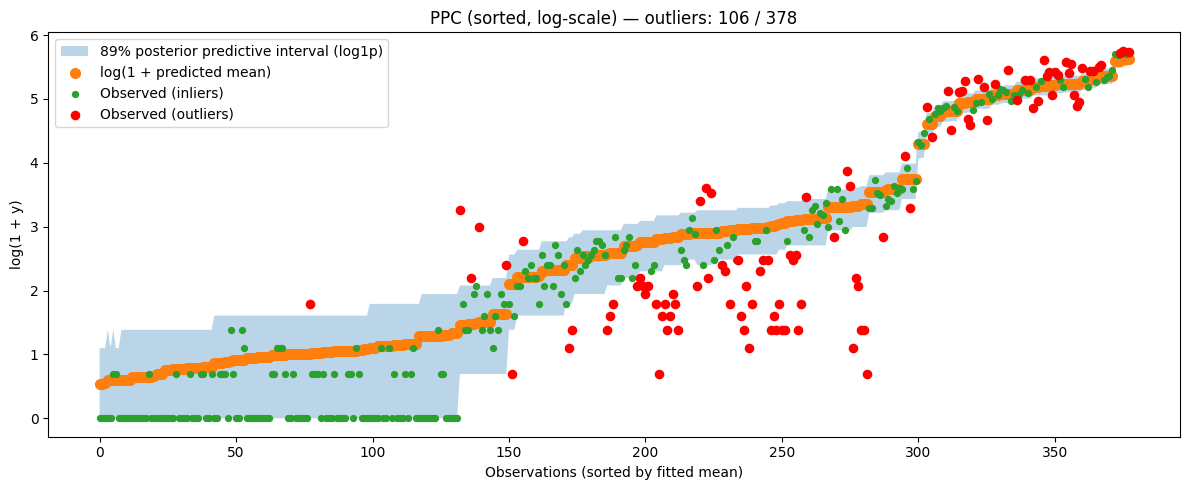

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

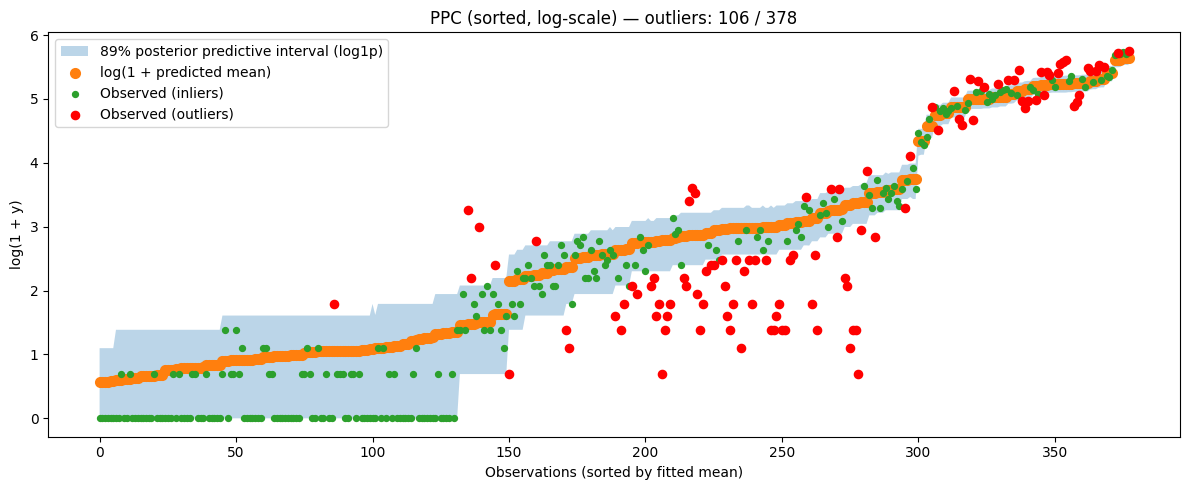

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X')


<Figure size 1000x500 with 0 Axes>

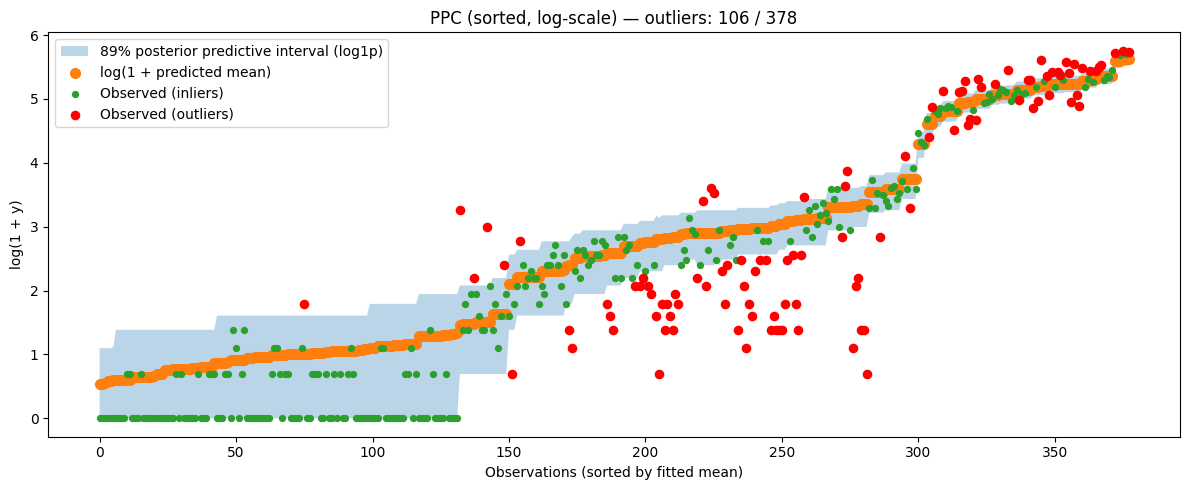

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

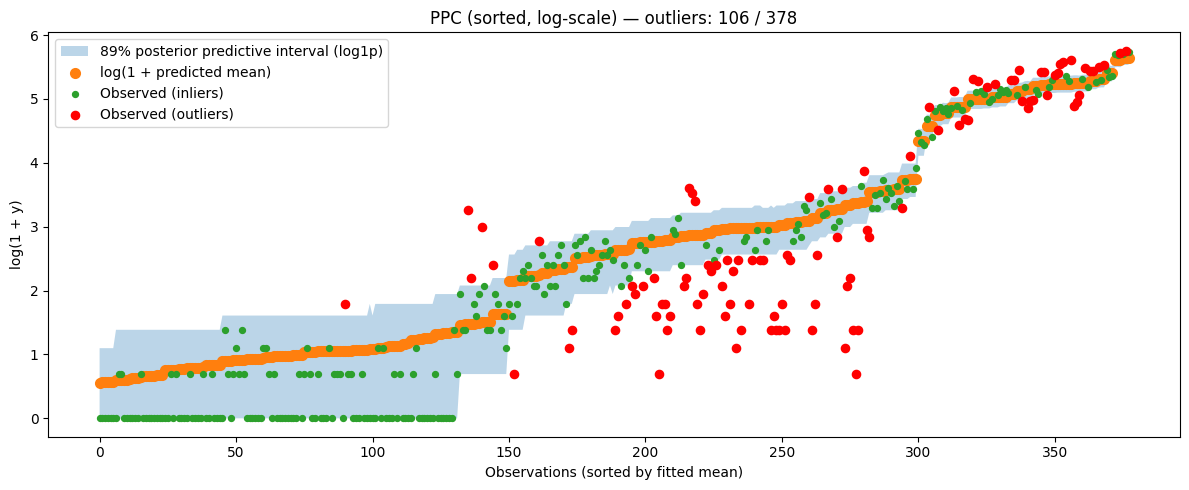

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


<Figure size 1000x500 with 0 Axes>

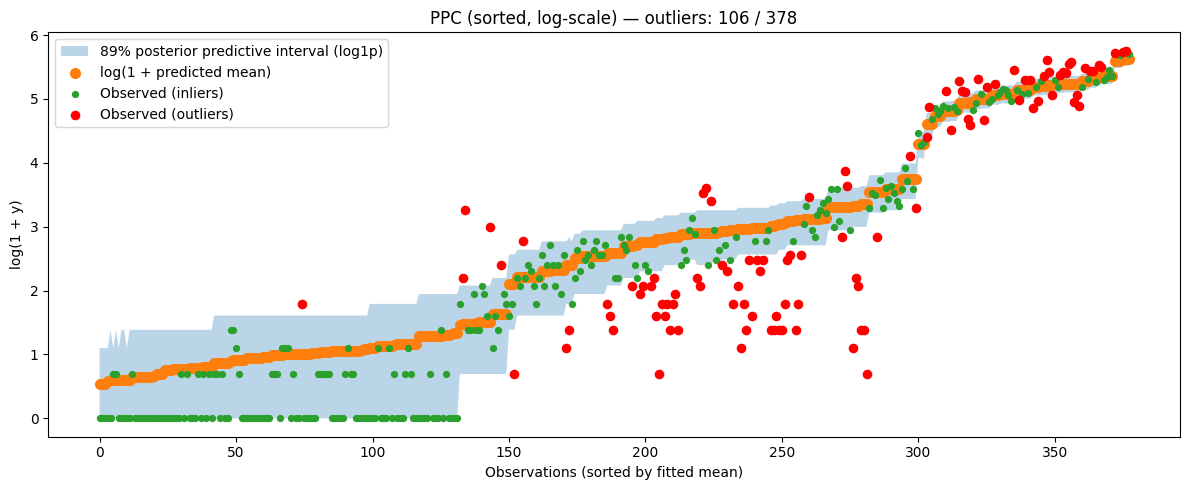

<Figure size 640x480 with 0 Axes>


('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 2.0), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 2.0), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

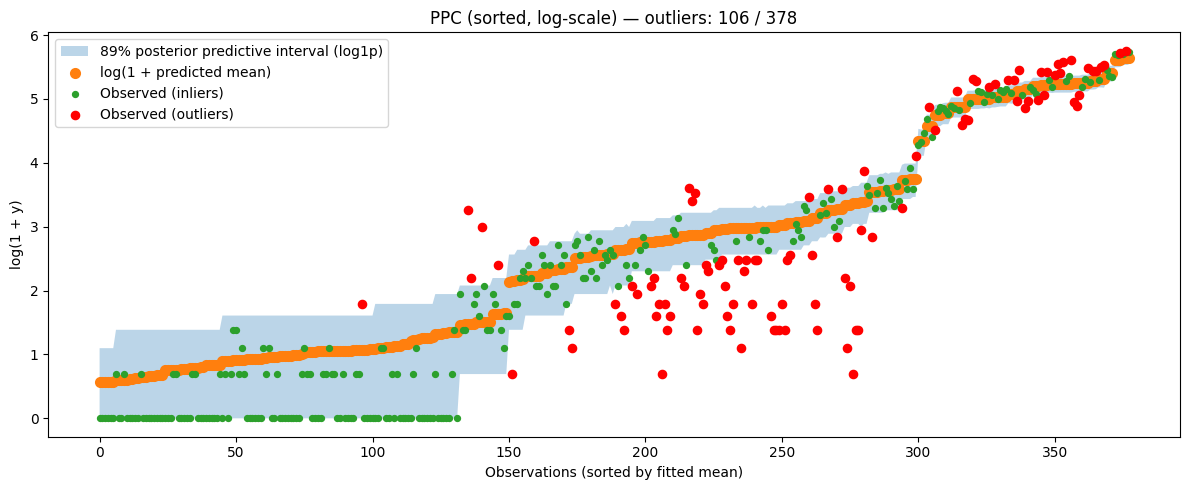

<Figure size 640x480 with 0 Axes>


('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X')


<Figure size 1000x500 with 0 Axes>

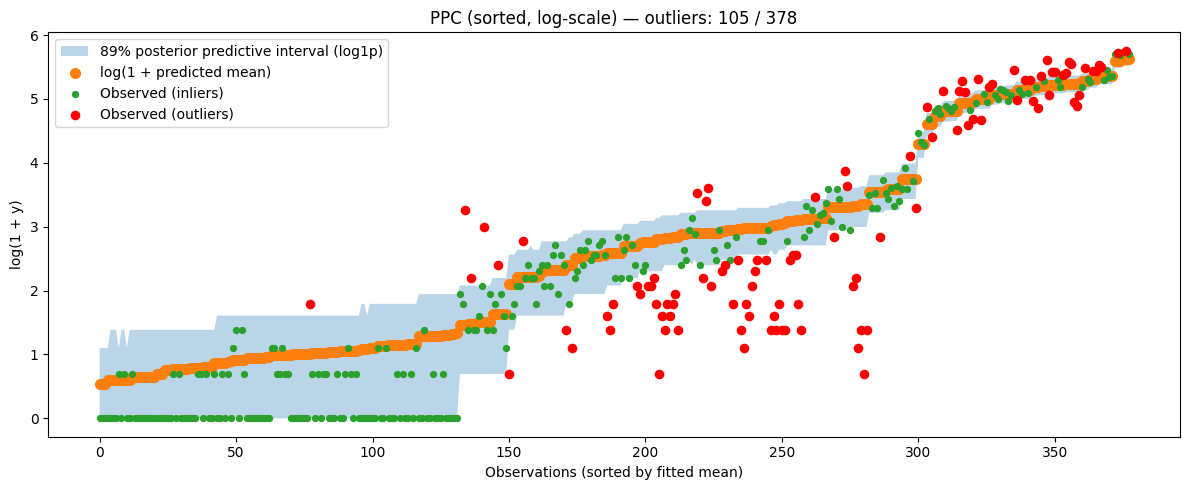

<Figure size 640x480 with 0 Axes>


('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

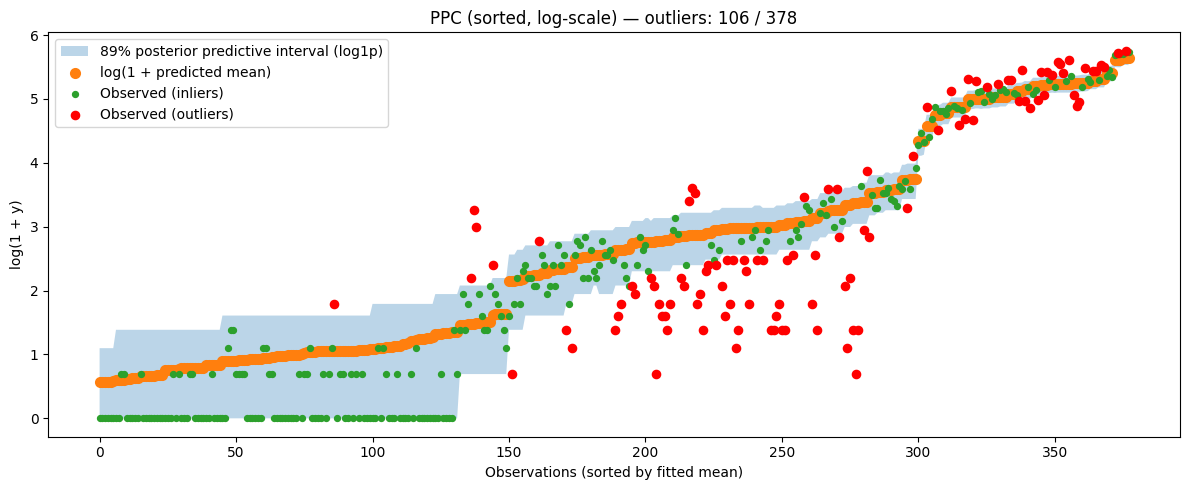

<Figure size 640x480 with 0 Axes>


('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


<Figure size 1000x500 with 0 Axes>

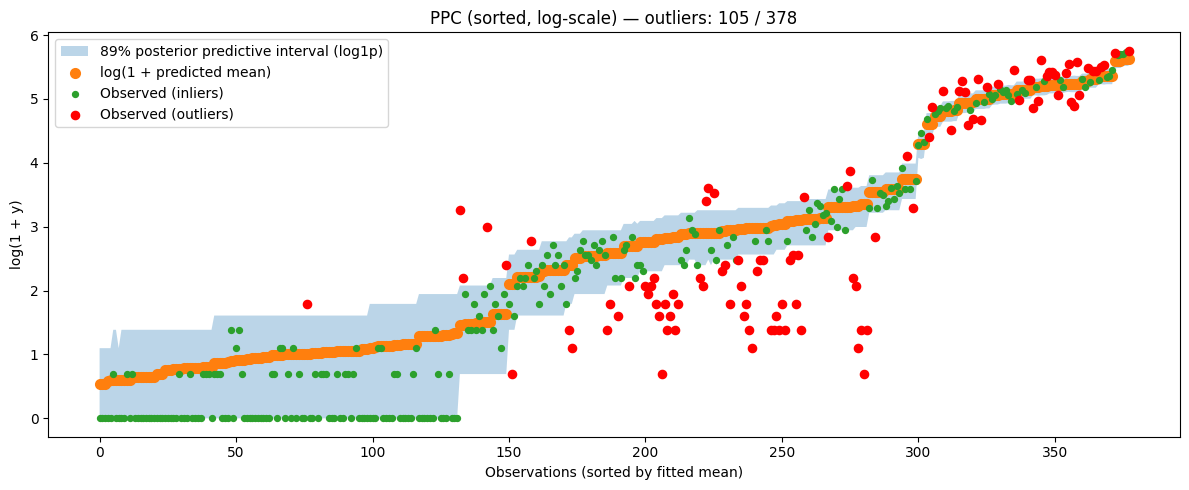

<Figure size 640x480 with 0 Axes>


('sr_tstudent.stan', (('student_df', 3), ('student_scale', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

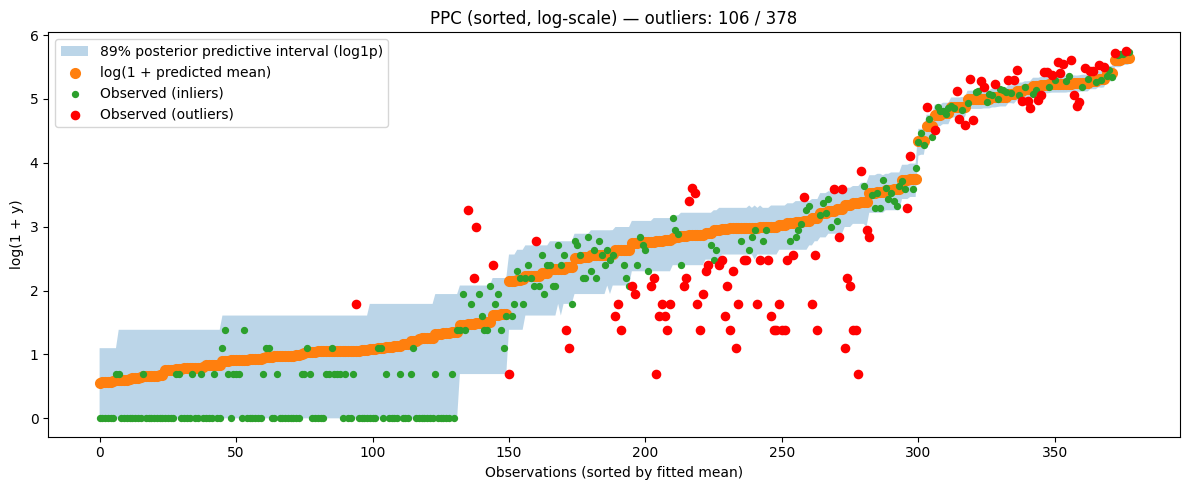

<Figure size 640x480 with 0 Axes>


('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X')


<Figure size 1000x500 with 0 Axes>

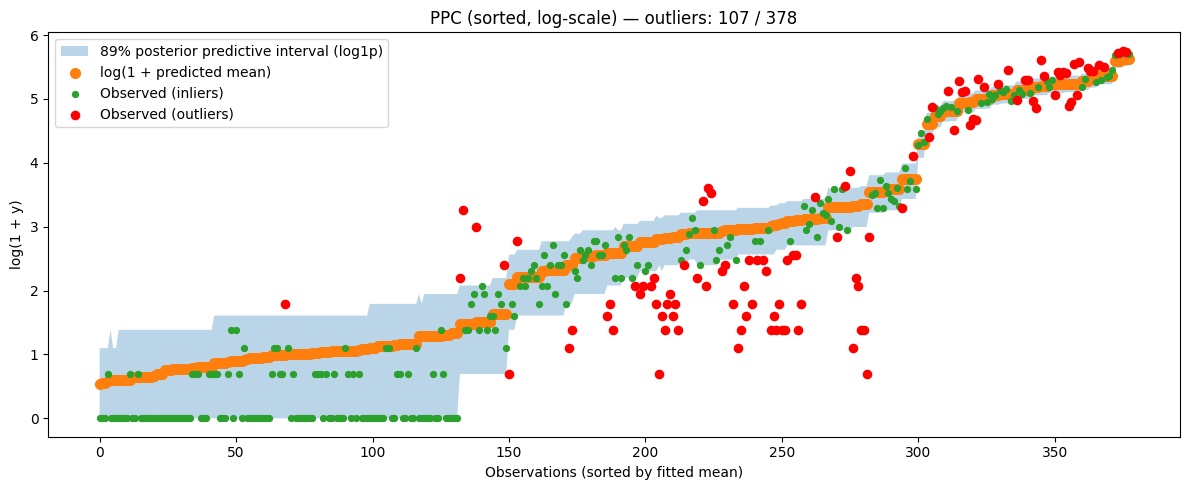

<Figure size 640x480 with 0 Axes>


('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 1)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

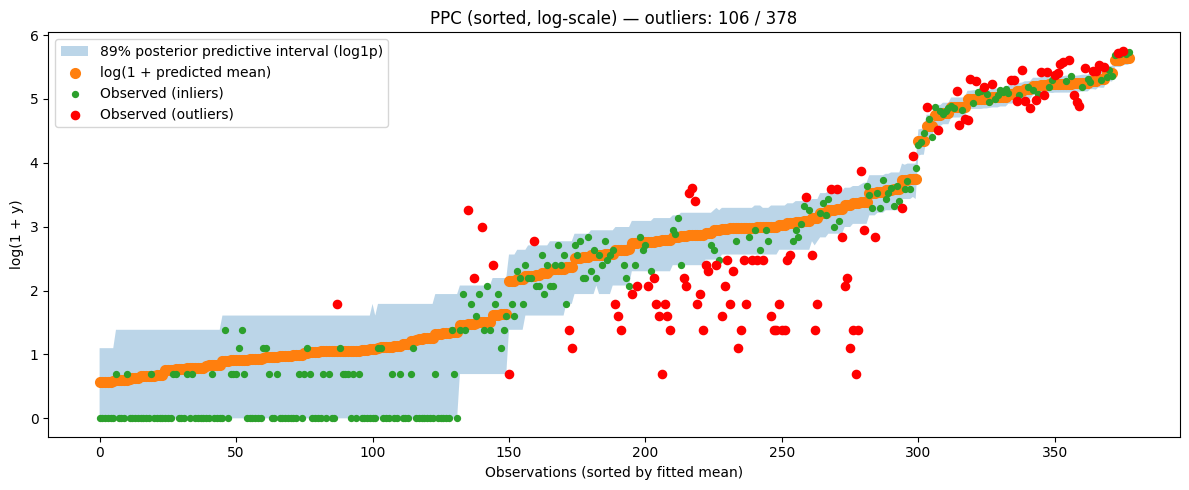

<Figure size 640x480 with 0 Axes>


('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


<Figure size 1000x500 with 0 Axes>

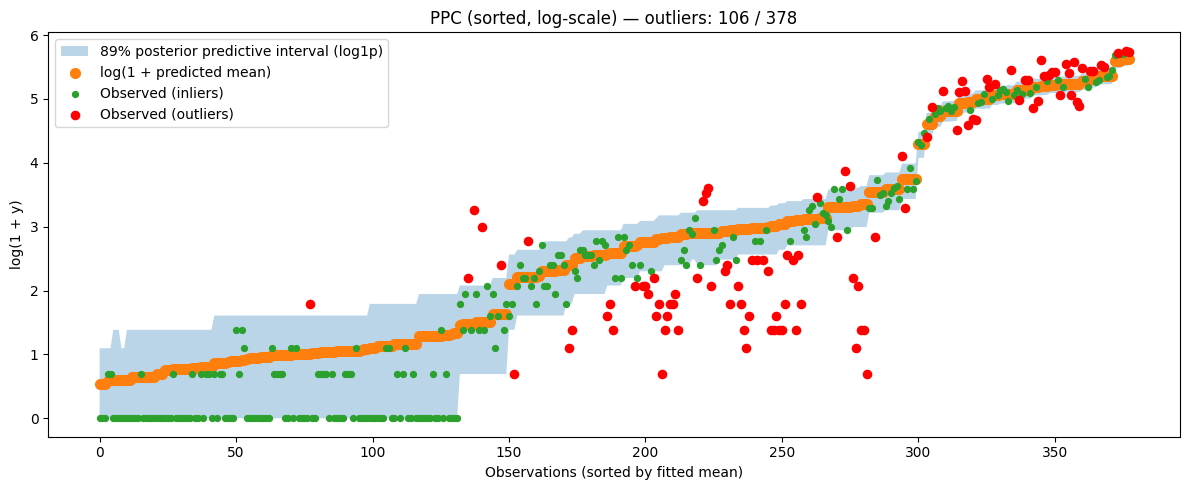

<Figure size 640x480 with 0 Axes>


('sr_halfnormal.stan', (('sigma_b', 0.5), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

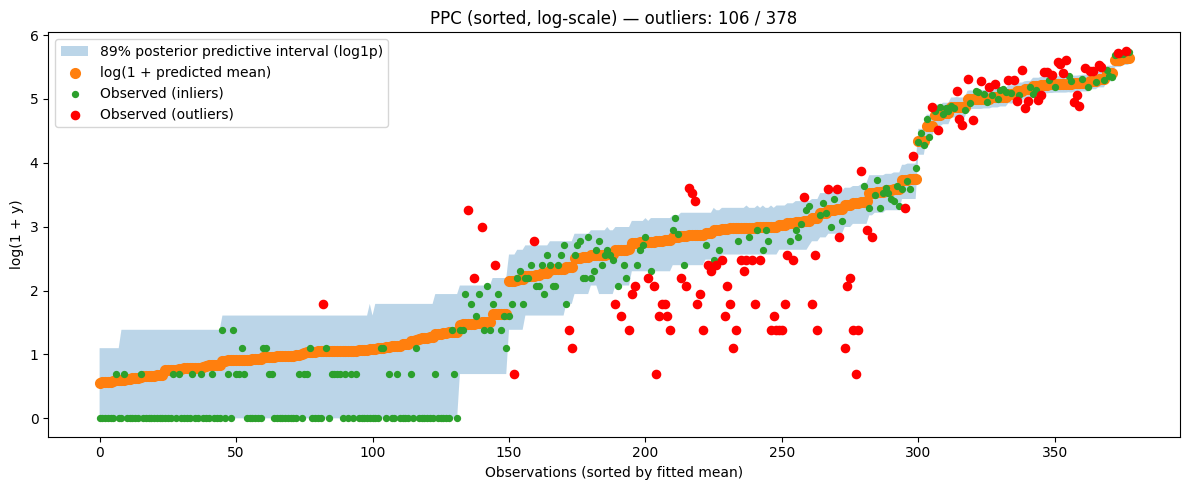

<Figure size 640x480 with 0 Axes>


('sr_halfnormal.stan', (('sigma_b', 1), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X')


<Figure size 1000x500 with 0 Axes>

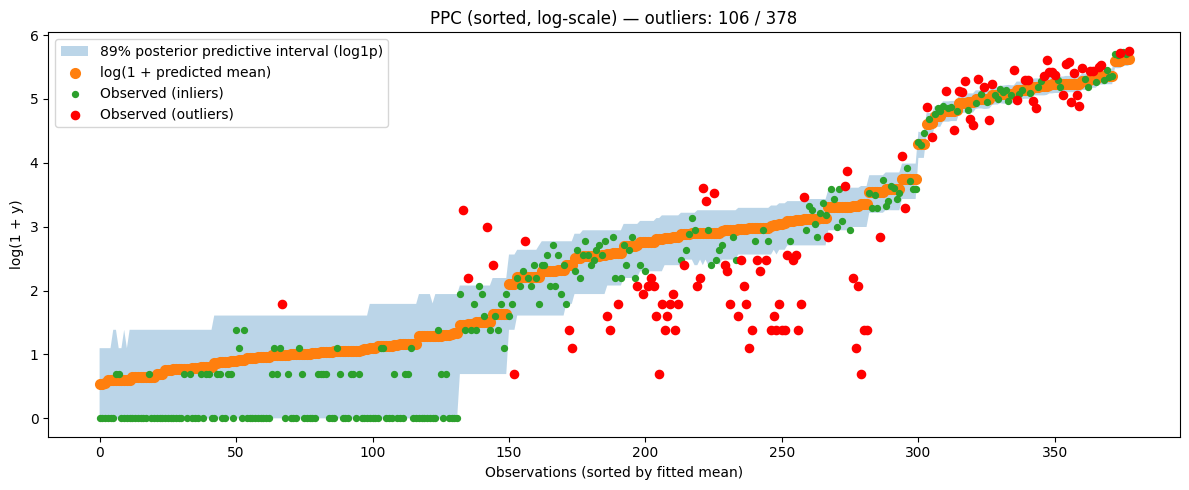

<Figure size 640x480 with 0 Axes>


('sr_halfnormal.stan', (('sigma_b', 1), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I')


<Figure size 1000x500 with 0 Axes>

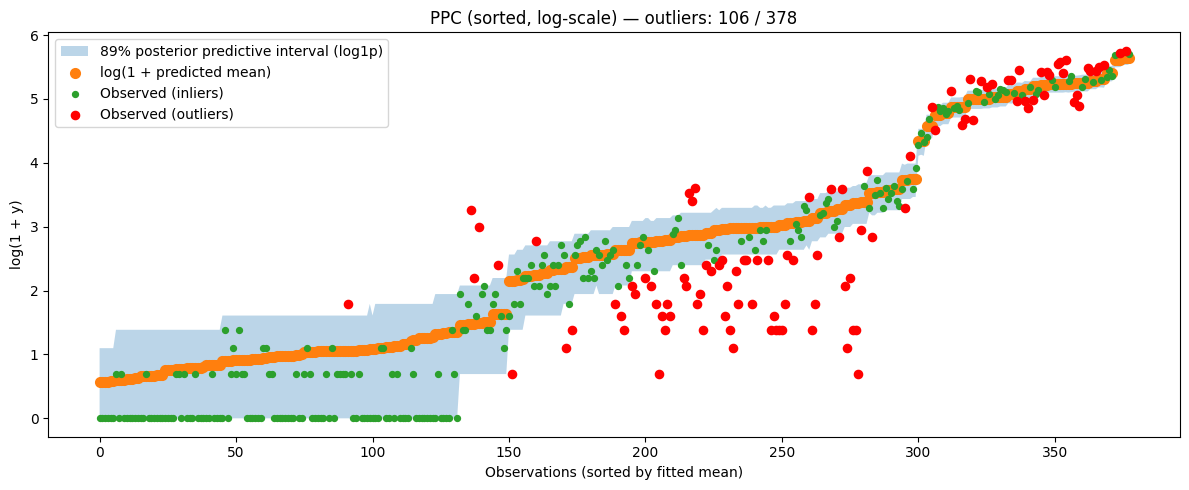

<Figure size 640x480 with 0 Axes>

In [16]:
#posterior predictive check

for key in models:
    print(f"\n{'='*60}")
    print(key)

    idata = models[key]["az"]  

    # Posterior predictive replicates: (chain, draw, N)
    yrep = idata.posterior["Y_rep"].values

    # Observed data 
    yobs = models[key]["data"]["Y"] 
    

    # Flatten chain+draw -> (S, N)
    S = yrep.shape[0] * yrep.shape[1]
    yrep = yrep.reshape(S, yrep.shape[2])

    # Plot
    plt.figure(figsize=(10, 5))
    posterior_predictive_check(yrep, yobs)
    plt.suptitle(f"Posterior Predictive Check: {key}", fontsize=16)
    plt.show()

### Compare Models 

In [17]:
compare_dict = {
}
for i,key in enumerate(models):
    compare_dict[i] = models[key]["az"]
    print(f"Added model {i}: {key} to comparison dict")

Added model 0: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') to comparison dict
Added model 1: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X2_I') to comparison dict
Added model 2: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X') to comparison dict
Added model 3: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.18), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.18), ('mu_alpha_0', 0), ('sigma_alpha_0', 10)), 'X2_I') to comparison dict
Added model 4: ('sr_invgamma.stan', (('tau_sq_a', 3), ('tau_sq_b', 0.72), ('sigma_beta_sq_a', 3), ('sigma_beta_sq_b', 0.72), ('mu_alpha_0', 0), ('sigma_alpha_0', 5)), 'X') to comparison dict
Added model 5: ('sr_invgamma.stan', (